## EDD-binned fitted yields, 2005 year FE, duration scenarios
## Fig 5 (b)

### Prerequisites
Same model outputs as notebook 4 (scripts `3_1` and `3_2`), plus the SSP climate file
`data/SSP/climate_future_scenario_2030s.csv`.

### Run order
Top to bottom, from a fresh kernel. **The original notebook's saved outputs were not
produced by a single clean pass** — its `execution_count` values ran 7…18 then jumped to
20, so at least one cell had been run and removed and the sequence did not start at 1.
Re-run from a fresh kernel before trusting any saved figure or table.

### Cleanup applied
Cell 6 originally re-defined `load_fields_for_year`, `prepare_field_chunk` and
`state_from_path`, all three of which cell 10 defines again. Cell 6's
`load_fields_for_year` **lacked the irrigation-history exclusion** that cell 10's
version applies. Nothing between cells 6 and 10 called any of the three, so the old
definitions were dead — but they were a trap if cells were ever re-run out of order, so
they have been removed from cell 6. Cell 10 is unchanged and remains the only definition.




# EDD-Binned Fitted Yields With a Common 2005 Year Fixed Effect

This self-contained notebook compares fitted corn and soybean yields across six climate-duration scenarios while holding the year fixed effect at its estimated 2005 value in every case:

1. 2000s weather (2000-2009) + 2005 duration;
2. 2000s weather (2000-2009) + continued low till through 2035;
3. delta-adjusted 2030s weather (SSP2-4.5; 2030-2039) + 2005 duration;
4. delta-adjusted 2030s weather (SSP2-4.5; 2030-2039) + continued low till through 2035;
5. delta-adjusted 2030s weather (SSP5-8.5; 2030-2039) + 2005 duration;
6. delta-adjusted 2030s weather (SSP5-8.5; 2030-2039) + continued low till through 2035.

Field fixed effects and the 2005 year fixed effect are common across scenarios, so differences reflect climate conditions and duration assumptions.

Future weather is bias-adjusted with a delta-change approach: PRISM observed 2000-2009 county weather plus the CMIP6 simulated change from the 2000s baseline to each future SSP scenario.


In [7]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")

# ============================== PORTABLE PATHS ==============================
# Set ROOT_OVERRIDE to the folder that contains "data/", or leave it "" to let the
# notebook find the project automatically (it searches the working directory and its
# parents, so it works as long as the notebook lives inside the project folder).
#
#   Google Drive (Mac)      "/Users/<you>/Library/CloudStorage/GoogleDrive-<you>@stanford.edu/My Drive/Research/Tillage_trend/Codex"
#   Google Drive (Windows)  "G:/My Drive/Research/Tillage_trend/Codex"
#   Colab                   mount the drive first, then point at the mounted path
ROOT_OVERRIDE = ""


def _find_project_root():
    import os as _os
    from pathlib import Path as _P

    def _ok(p):
        p = _P(p)
        return ((p / "data" / "Field_yield_tillage" / "processed_smooth_1999_2023").is_dir()
                and (p / "data" / "PRISM" / "PRISM_climate_1999_2023.csv").is_file())

    if ROOT_OVERRIDE:
        if not _ok(ROOT_OVERRIDE):
            raise FileNotFoundError(
                "ROOT_OVERRIDE is set to %r but that folder does not contain\n"
                "  data/Field_yield_tillage/processed_smooth_1999_2023/  and\n"
                "  data/PRISM/PRISM_climate_1999_2023.csv\n"
                "Fix the path, or set ROOT_OVERRIDE = \"\" for automatic detection."
                % ROOT_OVERRIDE)
        return _P(ROOT_OVERRIDE).resolve()

    seeds = []
    env = _os.environ.get("PROJECT_ROOT", "")
    if env:
        seeds.append(_P(env))
    for key in ("__vsc_ipynb_file__",):          # VS Code notebooks
        v = globals().get(key)
        if v:
            seeds.append(_P(v).parent)
    try:                                          # when exported to .py
        seeds.append(_P(__file__).parent)
    except NameError:
        pass
    seeds.append(_P.cwd())                        # Jupyter: the notebook's folder

    tried = []
    for s in seeds:
        for c in [s, *s.parents]:
            if c in tried:
                continue
            tried.append(c)
            if _ok(c):
                return _P(c).resolve()
    raise FileNotFoundError(
        "Could not locate the project root. Set ROOT_OVERRIDE at the top of this "
        "cell to the folder containing data/.\nSearched %d folder(s), starting from: %s"
        % (len(tried), ", ".join(str(t) for t in tried[:3])))


ROOT = _find_project_root()
print("Project root:", ROOT)
# ============================================================================
FIELD_DIR = ROOT / "data" / "Field_yield_tillage" / "processed_smooth_1999_2023"
PRISM_PATH = ROOT / "data" / "PRISM" / "PRISM_climate_1999_2023.csv"
OUTPUT_DIR = ROOT / "output_scenario_1999_2023" / "edd_binned_fitted_yields_2005_year_fe_duration_scenarios_no_irrigation"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CROPS = ["corn", "soy"]
CROP_LABELS = {"corn": "Corn", "soy": "Soybean"}
STATES = ["IA", "IL", "IN", "MI", "MN", "MO", "OH", "SD", "WI"]
CHUNKSIZE = 1_000_000

HISTORICAL_DURATION_YEAR = 2005
BASE_FIELD_YEAR = 2023
FUTURE_DURATION_YEAR = 2035
YEARS_TO_ADD = FUTURE_DURATION_YEAR - BASE_FIELD_YEAR
YEARS_BACK = BASE_FIELD_YEAR - HISTORICAL_DURATION_YEAR
HISTORICAL_WEATHER_YEARS = list(range(2000, 2010))
FUTURE_WEATHER_YEARS = list(range(2030, 2040))
REFERENCE_YEAR_FE = 2005

FOCAL_WEATHER_VAR = "EDD_6_9"
OTHER_WEATHER_CONTROL_VARS = ["GDD_4_5", "PPT_4_5", "GDD_6_9", "PPT_6_9"]
WEATHER_VARS = [*OTHER_WEATHER_CONTROL_VARS, FOCAL_WEATHER_VAR]
WEATHER_SOURCE_COLS = {
    "GDD_4_5": "GDD_4_5",
    "PPT_4_5": "ppt_4_5",
    "GDD_6_9": "GDD_6_9",
    "PPT_6_9": "ppt_6_9",
    "EDD_6_9": "EDD_6_9",
}
SCENARIO_LABELS = {"ssp245": "SSP2-4.5", "ssp585": "SSP5-8.5"}
CAP_PROJECTED_WEATHER_TO_MODEL_SUPPORT = False

MODEL_DIRS = {
    "corn": ROOT / "output_linear_1999_2023" / "3_1_corn_low_till_duration_weather_binning_edd69",
    "soy": ROOT / "output_linear_1999_2023" / "3_2_soy_low_till_duration_weather_binning_edd69",
}
IRRIGATION_HISTORY_PATH = ROOT / "data" / "irrigation" / "field_irrigation_ever_only_irrigated.csv"
FIELD_FILES = {
    crop: [
        FIELD_DIR / f"{crop}_yield_tillage_{state}_1999_2023.csv"
        for state in STATES
    ]
    for crop in CROPS
}
CLIMATE_SCENARIO_PATH = ROOT / "SSP" / "climate_future_scenario_2030s.csv"

SCENARIO_ORDER = [
    "2000s_2005_duration",
    "2000s_continued_low_till",
    "ssp245_2005_duration",
    "ssp245_continued_low_till",
    "ssp585_2005_duration",
    "ssp585_continued_low_till",
]
SCENARIO_LABEL_ORDER = [
    "2000s weather (2000-2009) + 2005 duration",
    "2000s weather (2000-2009) + continued low till",
    "2030s weather (SSP2-4.5) + 2005 duration",
    "2030s weather (SSP2-4.5) + continued low till",
    "2030s weather (SSP5-8.5) + 2005 duration",
    "2030s weather (SSP5-8.5) + continued low till",
]

USECOLS = [
    "OBJECTID", "yield", "size", "year", "till", "GEOID",
    "till_1_count", "till_1_streak", "till_0_count", "till_0_streak",
]

print(f"Project root: {ROOT}")
print(f"PRISM file: {PRISM_PATH}")
print(f"CMIP6 scenario file: {CLIMATE_SCENARIO_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex
PRISM file: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/data/PRISM/PRISM_climate_1999_2023.csv
CMIP6 scenario file: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/SSP/climate_future_scenario_2030s.csv
Output directory: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/output_scenario_1999_2023/edd_binned_fitted_yields_2005_year_fe_duration_scenarios_no_irrigation


## Load Mean Weather Conditions

In [8]:
def load_historical_prism_mean_weather() -> pd.DataFrame:
    usecols = ["FIPS", "year", *WEATHER_SOURCE_COLS.values()]
    prism = pd.read_csv(PRISM_PATH, usecols=usecols)
    prism["FIPS"] = pd.to_numeric(prism["FIPS"], errors="coerce").astype("Int64")
    prism["year"] = pd.to_numeric(prism["year"], errors="coerce")
    prism = prism.loc[prism["year"].isin(HISTORICAL_WEATHER_YEARS)].copy()
    for col in WEATHER_SOURCE_COLS.values():
        prism[col] = pd.to_numeric(prism[col], errors="coerce")
    agg = prism.groupby("FIPS", as_index=False).agg(
        **{col: (col, "mean") for col in WEATHER_SOURCE_COLS.values()},
        years_available=("year", "nunique"),
    )
    agg["period"] = "2000_2009"
    agg["period_label"] = "Observed 2000-2009"
    agg["scenario"] = "observed_2000_2009"
    agg["scenario_label"] = "Observed 2000-2009"
    return agg.dropna(subset=["FIPS"])


def load_cmip6_delta_adjusted_future_weather(historical_prism: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Construct future weather as PRISM 2000s weather plus CMIP6 simulated deltas.

    The SSP CSV contains CMIP6-simulated average weather for the 2000s baseline
    and future SSP scenarios. For each county and weather variable:

        adjusted future = PRISM observed 2000s + (CMIP6 future - CMIP6 2000s)

    This preserves the observed PRISM baseline while using CMIP6 for projected
    changes. Precipitation is clipped at zero after the additive delta step.
    """
    cmip = pd.read_csv(CLIMATE_SCENARIO_PATH)
    cmip["FIPS"] = pd.to_numeric(cmip["FIPS"], errors="coerce").astype("Int64")

    cmip_column_map = {
        "EDD_6_9": {
            "baseline": "EDD_2000s",
            "ssp245": "EDD_ssp245",
            "ssp585": "EDD_ssp585",
        },
        "GDD_4_5": {
            "baseline": "GDD_4_5_2000s",
            "ssp245": "GDD_4_5_ssp245",
            "ssp585": "GDD_4_5_ssp585",
        },
        "GDD_6_9": {
            "baseline": "GDD_6_9_2000s",
            "ssp245": "GDD_6_9_ssp245",
            "ssp585": "GDD_6_9_ssp585",
        },
        "PPT_4_5": {
            "baseline": "ppt_4_5_2000s",
            "ssp245": "ppt_4_5_ssp245",
            "ssp585": "ppt_4_5_ssp585",
        },
        "PPT_6_9": {
            "baseline": "ppt_6_9_2000s",
            "ssp245": "ppt_6_9_ssp245",
            "ssp585": "ppt_6_9_ssp585",
        },
    }

    required_cols = {"FIPS"}
    for mapping in cmip_column_map.values():
        required_cols.update(mapping.values())
    missing_cols = required_cols - set(cmip.columns)
    if missing_cols:
        raise ValueError(
            f"Missing required columns in {CLIMATE_SCENARIO_PATH}: {sorted(missing_cols)}"
        )

    for col in sorted(required_cols - {"FIPS"}):
        cmip[col] = pd.to_numeric(cmip[col], errors="coerce")

    base_cols = ["FIPS", *WEATHER_SOURCE_COLS.values()]
    prism_base = historical_prism[base_cols].copy()
    merged = prism_base.merge(cmip, on="FIPS", how="inner")

    adjusted_parts = []
    delta_parts = []
    for scenario in ["ssp245", "ssp585"]:
        out = merged[["FIPS"]].copy()
        delta = merged[["FIPS"]].copy()
        for weather_var, source_col in WEATHER_SOURCE_COLS.items():
            cmip_cols = cmip_column_map[weather_var]
            delta_col = f"{weather_var}_cmip6_delta_{scenario}"
            delta[delta_col] = (
                merged[cmip_cols[scenario]]
                - merged[cmip_cols["baseline"]]
            )
            out[source_col] = merged[source_col] + delta[delta_col]
            if weather_var.startswith("PPT_"):
                out[source_col] = out[source_col].clip(lower=0)
        out["period"] = "2030_2039"
        out["period_label"] = "Projected 2030-2039, delta-adjusted"
        out["scenario"] = scenario
        out["scenario_label"] = SCENARIO_LABELS[scenario]
        out["weather_adjustment_method"] = "PRISM_2000s_plus_CMIP6_future_minus_CMIP6_2000s"
        adjusted_parts.append(out)

        delta["scenario"] = scenario
        delta["scenario_label"] = SCENARIO_LABELS[scenario]
        delta_parts.append(delta)

    adjusted = pd.concat(adjusted_parts, ignore_index=True)
    deltas = pd.concat(delta_parts, ignore_index=True)
    return adjusted, deltas


historical_weather = load_historical_prism_mean_weather()
projected_weather, cmip6_delta_weather = load_cmip6_delta_adjusted_future_weather(historical_weather)
climate = pd.concat([historical_weather, projected_weather], ignore_index=True)

historical_weather.to_csv(OUTPUT_DIR / "county_observed_weather_2000_2009_mean.csv", index=False)
projected_weather.to_csv(OUTPUT_DIR / "county_projected_weather_2030_2039_delta_adjusted_by_ssp.csv", index=False)
cmip6_delta_weather.to_csv(OUTPUT_DIR / "county_cmip6_weather_deltas_2030s_minus_2000s_by_ssp.csv", index=False)

weather_summary = climate.groupby(["period_label", "scenario_label"], as_index=False).agg(
    counties=("FIPS", "nunique"),
    **{
        f"mean_{weather_var}": (source_col, "mean")
        for weather_var, source_col in WEATHER_SOURCE_COLS.items()
    },
)

display(weather_summary)
display(cmip6_delta_weather.head(20))

,period_label,scenario_label,counties,mean_GDD_4_5,mean_PPT_4_5,mean_GDD_6_9,mean_PPT_6_9,mean_EDD_6_9
0,Observed 2000-2009,Observed 2000-2009,1051,357.337686,180.909499,1517.478801,357.217023,23.144598
1,"Projected 2030-2039, delta-adjusted",SSP2-4.5,1050,420.035363,194.152833,1674.099048,354.579958,51.097770
2,"Projected 2030-2039, delta-adjusted",SSP5-8.5,1050,422.552122,189.042104,1700.060985,349.567583,60.226027


,FIPS,GDD_4_5_cmip6_delta_ssp245,PPT_4_5_cmip6_delta_ssp245,GDD_6_9_cmip6_delta_ssp245,PPT_6_9_cmip6_delta_ssp245,EDD_6_9_cmip6_delta_ssp245,scenario,scenario_label,GDD_4_5_cmip6_delta_ssp585,PPT_4_5_cmip6_delta_ssp585,GDD_6_9_cmip6_delta_ssp585,PPT_6_9_cmip6_delta_ssp585,EDD_6_9_cmip6_delta_ssp585
0,17001,73.172662,12.119507,158.414319,-0.331488,34.255844,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
1,17003,65.308560,12.371208,127.981649,-6.062879,48.130997,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
2,17005,70.198364,17.247868,140.899791,2.603579,37.272293,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
3,17007,65.118390,11.969132,158.642422,-3.837011,16.126295,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
4,17009,73.783430,13.902114,158.777875,-1.385723,32.279379,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
5,17011,69.946734,15.958016,159.373590,1.336852,23.216919,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
6,17013,73.117920,15.628476,145.193687,3.801535,36.924046,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
7,17015,68.691804,14.830415,162.657940,1.456798,18.451264,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
8,17017,73.455237,18.393504,156.170636,0.187480,31.194840,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN
9,17019,71.758623,17.737493,153.177095,2.065109,24.994362,ssp245,SSP2-4.5,NaN,NaN,NaN,NaN,NaN


In [9]:
OUTPUT_DIR

PosixPath('/Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/output_scenario_1999_2023/edd_binned_fitted_yields_2005_year_fe_duration_scenarios_no_irrigation')

## Load EDD-Binned Coefficients, Fixed Effects, and Field Helpers

In [10]:
# Load all coefficient tables directly from the model-output CSV files.
def pick_column(df: pd.DataFrame, candidates: list[str], role: str, required: bool = True):
    normalized = {re.sub(r"[^a-z0-9]+", "", c.lower()): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        key = re.sub(r"[^a-z0-9]+", "", cand.lower())
        if key in normalized:
            return normalized[key]
    if required:
        raise ValueError(f"Could not identify {role}. Available columns: {df.columns.tolist()}")
    return None


def standardize_slope_table(df: pd.DataFrame, estimate_candidates: list[str], se_candidates: list[str], estimate_out: str, se_out: str) -> pd.DataFrame:
    weather_col = pick_column(df, ["weather_var", "weather_variable", "weather_source_var", "variable", "var"], "weather variable column")
    bin_col = pick_column(df, ["weather_bin", "bin", "bin_label", "category"], "weather bin column")
    estimate_col = pick_column(df, estimate_candidates, estimate_out)
    se_col = pick_column(df, se_candidates, se_out)
    out = df.rename(columns={weather_col: "weather_var", bin_col: "weather_bin", estimate_col: estimate_out, se_col: se_out}).copy()
    out["weather_var"] = out["weather_var"].astype(str)
    out["weather_bin"] = out["weather_bin"].astype(str)
    out[estimate_out] = pd.to_numeric(out[estimate_out], errors="coerce")
    out[se_out] = pd.to_numeric(out[se_out], errors="coerce")
    return out[["weather_var", "weather_bin", estimate_out, se_out]]


def normalize_weather_name(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    for weather_var in WEATHER_VARS:
        if weather_var.lower() in text.lower():
            return weather_var
    return text


def standardize_duration_effects(df: pd.DataFrame, crop: str) -> pd.DataFrame:
    weather_col = pick_column(df, ["weather_var", "weather_source_var", "weather_variable", "variable", "var"], "weather variable column")
    bin_col = pick_column(df, ["weather_bin", "bin", "bin_label", "category"], "weather bin column")
    estimate_col = pick_column(
        df,
        ["estimate_log_points_per_year", "estimate", "effect", "coef", "coefficient", "tillage_duration_effect", "duration_effect", "log_yield_effect"],
        "per-year tillage duration effect estimate",
    )
    se_col = pick_column(df, ["std_error", "std.error", "se", "stderr", "standard_error", "effect_std_error", "duration_effect_std_error"], "per-year tillage duration effect standard error")
    out = df.copy()
    out["weather_var"] = out[weather_col].map(normalize_weather_name)
    out = out.loc[out["weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    out["weather_bin"] = out[bin_col].astype(str)
    out["tillage_duration_effect_per_year"] = pd.to_numeric(out[estimate_col], errors="coerce")
    out["tillage_duration_effect_per_year_std_error"] = pd.to_numeric(out[se_col], errors="coerce")
    out = out[["weather_var", "weather_bin", "tillage_duration_effect_per_year", "tillage_duration_effect_per_year_std_error"]].drop_duplicates()
    out["crop"] = crop
    return out


def standardize_additive_control_terms(df: pd.DataFrame, crop: str) -> pd.DataFrame:
    focal_col = pick_column(df, ["weather_var", "focal_weather_source_var", "focal_weather_var", "binned_weather_var", "weather_var_binned", "bin_weather_var", "focal_var"], "focal weather variable column")
    control_col = pick_column(df, ["additive_control", "control_weather_var", "control_var", "other_weather_var", "term", "variable", "var"], "additive weather control variable column")
    estimate_col = pick_column(df, ["estimate", "coef", "coefficient", "effect", "slope", "control_weather_slope", "additive_control_term"], "additive weather control estimate")
    se_col = pick_column(df, ["std_error", "std.error", "se", "stderr", "standard_error", "control_weather_slope_std_error", "additive_control_term_std_error"], "additive weather control standard error")
    out = df.copy()
    out["focal_weather_var"] = out[focal_col].map(normalize_weather_name)
    out = out.loc[out["focal_weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    out["control_weather_var"] = out[control_col].map(normalize_weather_name)
    out = out.loc[out["control_weather_var"].isin(OTHER_WEATHER_CONTROL_VARS)].copy()
    out["additive_control_slope"] = pd.to_numeric(out[estimate_col], errors="coerce")
    out["additive_control_slope_std_error"] = pd.to_numeric(out[se_col], errors="coerce")
    out = out[["control_weather_var", "additive_control_slope", "additive_control_slope_std_error"]].drop_duplicates()
    if out.empty:
        raise ValueError(f"No usable additive weather-control terms found for {crop} after filtering focal variable to {FOCAL_WEATHER_VAR}.")
    out["crop"] = crop
    return out


def standardize_bin_main_effects(df: pd.DataFrame, crop: str) -> pd.DataFrame:
    weather_col = pick_column(df, ["weather_var", "weather_source_var", "weather_variable", "variable", "var"], "weather variable column")
    term_col = pick_column(df, ["term", "coefficient", "coef_name", "name"], "term column")
    estimate_col = pick_column(df, ["estimate", "coef", "coefficient", "effect"], "weather-bin main effect estimate")
    se_col = pick_column(df, ["std_error", "std.error", "se", "stderr", "standard_error"], "weather-bin main effect standard error")
    out = df.copy()
    out["weather_var"] = out[weather_col].map(normalize_weather_name)
    out = out.loc[out["weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    out["term"] = out[term_col].astype(str)
    out = out.loc[out["term"].isin(["bin_middle", "bin_high"])].copy()
    out["weather_bin"] = out["term"].str.replace("bin_", "", regex=False)
    out["bin_main_effect"] = pd.to_numeric(out[estimate_col], errors="coerce")
    out["bin_main_effect_std_error"] = pd.to_numeric(out[se_col], errors="coerce")
    out = out[["weather_var", "weather_bin", "bin_main_effect", "bin_main_effect_std_error"]].drop_duplicates()
    low_row = pd.DataFrame({
        "weather_var": [FOCAL_WEATHER_VAR],
        "weather_bin": ["low"],
        "bin_main_effect": [0.0],
        "bin_main_effect_std_error": [0.0],
    })
    out = pd.concat([low_row, out], ignore_index=True)
    out["crop"] = crop
    return out


def load_coefficients_for_crop(crop: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    results_dir = MODEL_DIRS[crop]
    prefix = f"{crop}_linear_duration_weather_binning_edd69_with_other_weather_controls"
    paths = {
        "effects": results_dir / f"{prefix}_effects.csv",
        "control_weather_slopes": results_dir / f"{prefix}_control_weather_slopes.csv",
        "duration_weather_slopes": results_dir / f"{prefix}_duration_weather_slopes.csv",
        "additive_control_terms": results_dir / f"{prefix}_additive_control_terms.csv",
        "bin_stats": results_dir / f"{prefix}_bin_stats.csv",
        "terms": results_dir / f"{prefix}_terms.csv",
    }
    missing_paths = [name for name, path in paths.items() if not path.exists()]
    if missing_paths:
        raise FileNotFoundError(f"Missing expected {crop} model output files: {missing_paths}\n{paths}")

    effects_raw = pd.read_csv(paths["effects"])
    control_raw = pd.read_csv(paths["control_weather_slopes"])
    duration_raw = pd.read_csv(paths["duration_weather_slopes"])
    additive_raw = pd.read_csv(paths["additive_control_terms"])
    bins = pd.read_csv(paths["bin_stats"])
    terms_raw = pd.read_csv(paths["terms"])

    control = standardize_slope_table(
        control_raw,
        estimate_candidates=["control_weather_slope", "weather_slope", "slope", "estimate", "coef", "coefficient"],
        se_candidates=["control_weather_slope_std_error", "control_weather_slope_se", "std_error", "std.error", "se", "stderr", "standard_error"],
        estimate_out="edd_control_weather_slope",
        se_out="edd_control_weather_slope_std_error",
    )
    duration = standardize_slope_table(
        duration_raw,
        estimate_candidates=["slope_log_points_per_year_per_weather_unit", "duration_weather_slope", "low_till_duration_weather_slope", "slope", "estimate", "coef", "coefficient"],
        se_candidates=["slope_std_error", "duration_weather_slope_std_error", "duration_weather_slope_se", "std_error", "std.error", "se", "stderr", "standard_error"],
        estimate_out="edd_duration_weather_slope",
        se_out="edd_duration_weather_slope_std_error",
    )
    required_bin_cols = {"weather_var", "weather_bin", "weather_min", "weather_max", "weather_median", "trimmed_sample_p05", "trimmed_sample_p95"}
    missing = required_bin_cols - set(bins.columns)
    if missing:
        raise ValueError(f"{crop} bin_stats is missing columns: {sorted(missing)}")

    edd_bins = bins.loc[bins["weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    edd_coef = control.loc[control["weather_var"].eq(FOCAL_WEATHER_VAR)].merge(
        duration.loc[duration["weather_var"].eq(FOCAL_WEATHER_VAR)],
        on=["weather_var", "weather_bin"],
        how="left",
    ).merge(
        edd_bins[["weather_var", "weather_bin", "weather_min", "weather_max", "weather_median", "trimmed_sample_p05", "trimmed_sample_p95"]],
        on=["weather_var", "weather_bin"],
        how="left",
    )
    edd_coef["crop"] = crop

    tillage_duration_effects = standardize_duration_effects(effects_raw, crop)
    additive_controls = standardize_additive_control_terms(additive_raw, crop)
    bin_main_effects = standardize_bin_main_effects(terms_raw, crop)
    return edd_coef, additive_controls, tillage_duration_effects, bin_main_effects

loaded = {crop: load_coefficients_for_crop(crop) for crop in CROPS}
edd_coef_tables = {crop: value[0] for crop, value in loaded.items()}
additive_control_tables = {crop: value[1] for crop, value in loaded.items()}
tillage_duration_effect_tables = {crop: value[2] for crop, value in loaded.items()}
bin_main_effect_tables = {crop: value[3] for crop, value in loaded.items()}
edd_coef_df = pd.concat(edd_coef_tables.values(), ignore_index=True)
additive_control_coef_df = pd.concat(additive_control_tables.values(), ignore_index=True)
tillage_duration_effect_df = pd.concat(tillage_duration_effect_tables.values(), ignore_index=True)
bin_main_effect_df = pd.concat(bin_main_effect_tables.values(), ignore_index=True)

edd_coef_df.to_csv(OUTPUT_DIR / "edd_binned_coefficients_used_by_crop.csv", index=False)
additive_control_coef_df.to_csv(OUTPUT_DIR / "additive_weather_control_terms_used_by_crop.csv", index=False)
tillage_duration_effect_df.to_csv(OUTPUT_DIR / "tillage_duration_effects_used_by_crop.csv", index=False)
bin_main_effect_df.to_csv(OUTPUT_DIR / "weather_bin_main_effects_used_by_crop.csv", index=False)


def load_vcov_matrix_for_crop(crop: str) -> pd.DataFrame:
    results_dir = MODEL_DIRS[crop]
    prefix = f"{crop}_linear_duration_weather_binning_edd69_with_other_weather_controls"
    vcov_path = results_dir / f"{prefix}_vcov.csv"
    if not vcov_path.exists():
        print(f"No VCOV file found for {crop}; using independent-SE fallback for uncertainty.")
        return pd.DataFrame()

    raw = pd.read_csv(vcov_path)
    if {"V1", "V2", "N"}.issubset(raw.columns):
        raw = raw.rename(columns={"V1": "term_1", "V2": "term_2", "N": "covariance"})
    elif {"term_1", "term_2", "covariance"}.issubset(raw.columns):
        raw = raw.rename(columns={"term_1": "term_1", "term_2": "term_2", "covariance": "covariance"})
    else:
        term_1 = pick_column(raw, ["term_1", "row", "row_term", "coef_1", "coefficient_1", "var1", "name1"], "VCOV row term")
        term_2 = pick_column(raw, ["term_2", "col", "col_term", "coef_2", "coefficient_2", "var2", "name2"], "VCOV column term")
        covariance = pick_column(raw, ["covariance", "cov", "value", "vcov", "N"], "VCOV covariance value")
        raw = raw.rename(columns={term_1: "term_1", term_2: "term_2", covariance: "covariance"})

    raw["term_1"] = raw["term_1"].astype(str)
    raw["term_2"] = raw["term_2"].astype(str)
    raw["covariance"] = pd.to_numeric(raw["covariance"], errors="coerce")
    raw = raw.dropna(subset=["covariance"])

    if "model" in raw.columns:
        model_mask = raw["model"].astype(str).str.contains(FOCAL_WEATHER_VAR, case=False, regex=False)
        if model_mask.any():
            raw = raw.loc[model_mask].copy()
    if "model_name" in raw.columns:
        model_mask = raw["model_name"].astype(str).str.contains(FOCAL_WEATHER_VAR, case=False, regex=False)
        if model_mask.any():
            raw = raw.loc[model_mask].copy()

    matrix = raw.pivot_table(
        index="term_1",
        columns="term_2",
        values="covariance",
        aggfunc="first",
    )
    all_terms = matrix.index.union(matrix.columns)
    matrix = matrix.reindex(index=all_terms, columns=all_terms)
    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.fillna(0.0)
    matrix.index = matrix.index.astype(str)
    matrix.columns = matrix.columns.astype(str)
    return matrix


vcov_matrices = {crop: load_vcov_matrix_for_crop(crop) for crop in CROPS}
vcov_diagnostics = pd.DataFrame([
    {
        "crop": crop,
        "vcov_terms": len(vcov),
        "min_diagonal": float(np.nanmin(np.diag(vcov.to_numpy(dtype=float)))) if len(vcov) else np.nan,
        "max_diagonal": float(np.nanmax(np.diag(vcov.to_numpy(dtype=float)))) if len(vcov) else np.nan,
    }
    for crop, vcov in vcov_matrices.items()
])
vcov_diagnostics.to_csv(OUTPUT_DIR / "vcov_diagnostics_by_crop.csv", index=False)

display(edd_coef_df)
display(additive_control_coef_df)
display(tillage_duration_effect_df)
display(bin_main_effect_df)
display(vcov_diagnostics)


# Load field and year fixed effects directly from the saved model outputs.
def normalize_model_weather(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    for weather_var in WEATHER_VARS:
        if weather_var.lower() in text.lower():
            return weather_var
    return text


def standardize_fixed_effect_table(df: pd.DataFrame, crop: str, effect_type: str) -> pd.DataFrame:
    model_col = pick_column(
        df,
        ["weather_var", "focal_weather_var", "model", "model_name"],
        f"{effect_type} model/weather column",
        required=False,
    )
    if model_col is not None:
        normalized_model = df[model_col].map(normalize_model_weather)
        keep = normalized_model.eq(FOCAL_WEATHER_VAR)
        if keep.any():
            df = df.loc[keep].copy()

    if effect_type == "field":
        id_col = pick_column(
            df,
            ["OBJECTID", "fixed_effect_id", "field_id", "id", "level"],
            "field fixed-effect identifier",
        )
        value_col = pick_column(
            df,
            ["field_fixed_effect", "fixed_effect_value", "fixef", "fixed_effect", "estimate", "effect", "value"],
            "field fixed-effect value",
        )
        out = df[[id_col, value_col]].rename(
            columns={id_col: "OBJECTID", value_col: "field_fixed_effect"}
        )
        out["OBJECTID"] = out["OBJECTID"].astype(str)
        out["field_fixed_effect"] = pd.to_numeric(out["field_fixed_effect"], errors="coerce")
        out = out.dropna(subset=["OBJECTID", "field_fixed_effect"]).drop_duplicates("OBJECTID")
    else:
        id_col = pick_column(
            df,
            ["year", "fixed_effect_id", "year_id", "id", "level"],
            "year fixed-effect identifier",
        )
        value_col = pick_column(
            df,
            ["year_fixed_effect", "fixed_effect_value", "fixef", "fixed_effect", "estimate", "effect", "value"],
            "year fixed-effect value",
        )
        out = df[[id_col, value_col]].rename(
            columns={id_col: "year", value_col: "year_fixed_effect"}
        )
        out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
        out["year_fixed_effect"] = pd.to_numeric(out["year_fixed_effect"], errors="coerce")
        out = out.dropna(subset=["year", "year_fixed_effect"]).drop_duplicates("year")

    out["crop"] = crop
    return out


def load_fixed_effects_for_crop(crop: str):
    results_dir = MODEL_DIRS[crop]
    prefix = f"{crop}_linear_duration_weather_binning_edd69_with_other_weather_controls"
    field_path = results_dir / f"{prefix}_field_fixed_effects.csv"
    year_path = results_dir / f"{prefix}_year_fixed_effects.csv"
    if not field_path.exists():
        raise FileNotFoundError(field_path)
    if not year_path.exists():
        raise FileNotFoundError(year_path)
    field_fe = standardize_fixed_effect_table(pd.read_csv(field_path), crop, "field")
    year_fe = standardize_fixed_effect_table(pd.read_csv(year_path), crop, "year")
    return field_fe, year_fe


fixed_effect_tables = {
    crop: load_fixed_effects_for_crop(crop)
    for crop in CROPS
}
field_fe_tables = {
    crop: tables[0]
    for crop, tables in fixed_effect_tables.items()
}
year_fe_tables = {
    crop: tables[1]
    for crop, tables in fixed_effect_tables.items()
}


# Load and filter field-year records directly from the processed field files.
def pct_from_log(x):
    return 100.0 * np.expm1(x)

,weather_var,weather_bin,edd_control_weather_slope,edd_control_weather_slope_std_error,edd_duration_weather_slope,edd_duration_weather_slope_std_error,weather_min,weather_max,weather_median,trimmed_sample_p05,trimmed_sample_p95,crop
0,EDD_6_9,low,-0.009661,0.001951,-0.000534,0.000194,0.000000,4.647311,2.099847,0.932105,43.551095,corn
1,EDD_6_9,middle,-0.007335,0.000564,-0.000020,0.000036,4.647969,18.998757,10.024067,0.932105,43.551095,corn
2,EDD_6_9,high,-0.010604,0.000363,0.000132,0.000031,18.999173,135.136529,28.373285,0.932105,43.551095,corn
3,EDD_6_9,low,-0.007066,0.001510,-0.000728,0.000147,0.000000,5.092529,2.338095,1.080032,46.466490,soy
4,EDD_6_9,middle,-0.005916,0.000436,0.000021,0.000028,5.092630,21.141157,11.253449,1.080032,46.466490,soy
5,EDD_6_9,high,-0.006497,0.000213,0.000094,0.000016,21.142222,135.136529,31.254799,1.080032,46.466490,soy


,control_weather_var,additive_control_slope,additive_control_slope_std_error,crop
0,GDD_4_5,0.000273,0.000045,corn
1,PPT_4_5,-0.000204,0.000014,corn
2,GDD_6_9,0.000040,0.000037,corn
3,PPT_6_9,0.000016,0.000011,corn
4,GDD_4_5,0.000586,0.000037,soy
5,PPT_4_5,-0.000118,0.000014,soy
6,GDD_6_9,0.000064,0.000025,soy
7,PPT_6_9,0.000074,0.000010,soy


,weather_var,weather_bin,tillage_duration_effect_per_year,tillage_duration_effect_per_year_std_error,crop
0,EDD_6_9,low,0.002299,0.000443,corn
1,EDD_6_9,middle,0.001052,0.000308,corn
2,EDD_6_9,high,0.002960,0.000305,corn
3,EDD_6_9,low,0.000600,0.000296,soy
4,EDD_6_9,middle,0.000771,0.000220,soy
5,EDD_6_9,high,0.003732,0.000271,soy


,weather_var,weather_bin,bin_main_effect,bin_main_effect_std_error,crop
0,EDD_6_9,low,0.000000,0.000000,corn
1,EDD_6_9,middle,-0.067906,0.004742,corn
2,EDD_6_9,high,-0.220353,0.010021,corn
3,EDD_6_9,low,0.000000,0.000000,soy
4,EDD_6_9,middle,-0.074998,0.005667,soy
5,EDD_6_9,high,-0.216578,0.010198,soy


,crop,vcov_terms,min_diagonal,max_diagonal
0,corn,15,1.218760e-10,0.000100
1,soy,15,9.919033e-11,0.000104


## Assign EDD Bins and Additive Weather Controls

In [11]:
def assign_weather_bin(value, rows):
    if not np.isfinite(value):
        return np.nan
    low_max = float(rows.loc[rows["weather_bin"].eq("low"), "weather_max"].iloc[0])
    middle_max = float(rows.loc[rows["weather_bin"].eq("middle"), "weather_max"].iloc[0])
    if value <= low_max:
        return "low"
    if value <= middle_max:
        return "middle"
    return "high"


def assign_edd_bins_for_crop(crop, climate_df):
    rows = edd_coef_tables[crop].copy()
    source_col = WEATHER_SOURCE_COLS[FOCAL_WEATHER_VAR]
    id_cols = ["FIPS", "period", "period_label", "scenario", "scenario_label"]
    out = climate_df[id_cols + [source_col]].rename(
        columns={source_col: "edd_value_raw"}
    )
    out["crop"] = crop
    out["weather_var"] = FOCAL_WEATHER_VAR
    support_min = float(rows["trimmed_sample_p05"].iloc[0])
    support_max = float(rows["trimmed_sample_p95"].iloc[0])
    out["outside_model_support"] = (
        out["edd_value_raw"].lt(support_min)
        | out["edd_value_raw"].gt(support_max)
    )
    out["edd_value"] = out["edd_value_raw"]
    if CAP_PROJECTED_WEATHER_TO_MODEL_SUPPORT:
        is_projected = out["period"].eq("2030_2039")
        out.loc[is_projected, "edd_value"] = out.loc[is_projected, "edd_value_raw"].clip(
            support_min, support_max
        )
    out["weather_bin"] = out["edd_value"].apply(
        lambda value: assign_weather_bin(float(value), rows)
    )
    out = out.merge(
        rows,
        on=["crop", "weather_var", "weather_bin"],
        how="left",
    )
    out["edd_centered"] = out["edd_value"] - out["weather_median"]
    return out


def build_additive_weather_controls(crop, climate_df):
    id_cols = ["FIPS", "period", "period_label", "scenario", "scenario_label"]
    parts = []
    for weather_var in OTHER_WEATHER_CONTROL_VARS:
        source_col = WEATHER_SOURCE_COLS[weather_var]
        part = climate_df[id_cols + [source_col]].rename(
            columns={source_col: "weather_value"}
        )
        part["crop"] = crop
        part["control_weather_var"] = weather_var
        part = part.merge(
            additive_control_tables[crop],
            on=["crop", "control_weather_var"],
            how="left",
        )
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


edd_bins = {
    crop: assign_edd_bins_for_crop(crop, climate)
    for crop in CROPS
}
additive_weather_controls = {
    crop: build_additive_weather_controls(crop, climate)
    for crop in CROPS
}

edd_bins_df = pd.concat(edd_bins.values(), ignore_index=True)
additive_weather_controls_df = pd.concat(additive_weather_controls.values(), ignore_index=True)
edd_bins_df.to_csv(OUTPUT_DIR / "edd_bin_assignments_by_crop.csv", index=False)
additive_weather_controls_df.to_csv(OUTPUT_DIR / "additive_weather_controls_by_crop.csv", index=False)

support = edd_bins_df.groupby(
    ["crop", "period_label", "scenario_label", "weather_var"],
    as_index=False,
).agg(
    counties=("FIPS", "nunique"),
    outside_model_support_counties=("outside_model_support", "sum"),
    mean_edd=("edd_value_raw", "mean"),
    min_edd=("edd_value_raw", "min"),
    max_edd=("edd_value_raw", "max"),
)
support["outside_model_support_county_share_pct"] = (
    100 * support["outside_model_support_counties"] / support["counties"]
)
support.to_csv(OUTPUT_DIR / "edd_support_diagnostics_by_crop.csv", index=False)

display(support)
display(additive_weather_controls_df.head(20))

,crop,period_label,scenario_label,weather_var,counties,outside_model_support_counties,mean_edd,min_edd,max_edd,outside_model_support_county_share_pct
0,corn,Observed 2000-2009,Observed 2000-2009,EDD_6_9,1051,171,23.144598,0.028205,114.389118,16.270219
1,corn,"Projected 2030-2039, delta-adjusted",SSP2-4.5,EDD_6_9,1050,487,51.097770,1.534933,186.517273,46.380952
2,corn,"Projected 2030-2039, delta-adjusted",SSP5-8.5,EDD_6_9,1050,554,60.226027,2.338340,209.012097,52.761905
3,soy,Observed 2000-2009,Observed 2000-2009,EDD_6_9,1051,155,23.144598,0.028205,114.389118,14.747859
4,soy,"Projected 2030-2039, delta-adjusted",SSP2-4.5,EDD_6_9,1050,460,51.097770,1.534933,186.517273,43.809524
5,soy,"Projected 2030-2039, delta-adjusted",SSP5-8.5,EDD_6_9,1050,531,60.226027,2.338340,209.012097,50.571429


,FIPS,period,period_label,scenario,scenario_label,weather_value,crop,control_weather_var,additive_control_slope,additive_control_slope_std_error
0,17001,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,438.382783,corn,GDD_4_5,0.000273,0.000045
1,17003,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,572.068561,corn,GDD_4_5,0.000273,0.000045
2,17005,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,482.775686,corn,GDD_4_5,0.000273,0.000045
3,17007,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,315.165386,corn,GDD_4_5,0.000273,0.000045
4,17009,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,434.620799,corn,GDD_4_5,0.000273,0.000045
5,17011,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,373.861015,corn,GDD_4_5,0.000273,0.000045
6,17013,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,487.323730,corn,GDD_4_5,0.000273,0.000045
7,17015,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,338.033586,corn,GDD_4_5,0.000273,0.000045
8,17017,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,438.703327,corn,GDD_4_5,0.000273,0.000045
9,17019,2000_2009,Observed 2000-2009,observed_2000_2009,Observed 2000-2009,415.944761,corn,GDD_4_5,0.000273,0.000045


## Build Eligible 2023 Field Samples and Attach 2005 Durations

In [12]:
USECOLS = [
    "OBJECTID", "yield", "size", "year", "till", "GEOID",
    "till_1_count", "till_1_streak", "till_0_count", "till_0_streak",
]


def state_from_path(path: Path, crop: str) -> str:
    match = re.search(rf"{crop}_yield_tillage_([A-Z]{{2}})_(?:1999|2001)_2023", path.name)
    return match.group(1) if match else "NA"


def load_irrigated_history_ids() -> set[str]:
    if not IRRIGATION_HISTORY_PATH.exists():
        print(f"No irrigation-history file found at {IRRIGATION_HISTORY_PATH}; no irrigation filter applied.")
        return set()
    ids = pd.read_csv(IRRIGATION_HISTORY_PATH, usecols=["OBJECTID"])
    return set(ids["OBJECTID"].astype(str))


IRRIGATED_HISTORY_OBJECTIDS = load_irrigated_history_ids()
print(f"Irrigation-history fields excluded from scenario sample: {len(IRRIGATED_HISTORY_OBJECTIDS):,}")


def prepare_field_chunk(chunk: pd.DataFrame, source_state: str, target_year: int) -> pd.DataFrame:
    chunk = chunk.copy()
    chunk["state"] = source_state
    chunk = chunk.rename(columns={"GEOID": "FIPS"})
    for col in ["year", "till", "till_1_count", "till_1_streak", "till_0_count", "till_0_streak", "FIPS"]:
        chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
    chunk["yield_per_1000_units"] = pd.to_numeric(chunk["yield"], errors="coerce") / 1000.0
    chunk["size"] = pd.to_numeric(chunk["size"], errors="coerce")
    chunk = chunk.loc[
        np.isfinite(chunk["yield_per_1000_units"]) & (chunk["yield_per_1000_units"] > 0) &
        np.isfinite(chunk["size"]) & (chunk["size"] > 0) &
        chunk["year"].eq(target_year) & chunk["till"].isin([0, 1]) & chunk["FIPS"].notna()
    ].copy()
    chunk["year"] = chunk["year"].astype(int)
    chunk["till"] = chunk["till"].astype(int)
    chunk["FIPS"] = chunk["FIPS"].astype("Int64")
    chunk["clean_control"] = chunk["till"].eq(0) & chunk["till_1_count"].eq(0)
    chunk["continuous_low_till"] = (
        chunk["till"].eq(1)
        & chunk["till_1_count"].eq(chunk["till_1_streak"])
        & chunk["till_1_streak"].ge(1)
    )
    chunk = chunk.loc[chunk["clean_control"] | chunk["continuous_low_till"]].copy()
    chunk["duration_observed"] = np.where(
        chunk["continuous_low_till"], chunk["till_1_streak"], 0
    ).astype(float)
    return chunk


def load_fields_for_year(crop: str, target_year: int) -> pd.DataFrame:
    parts = []
    for file in FIELD_FILES[crop]:
        state = state_from_path(file, crop)
        for chunk in pd.read_csv(file, usecols=USECOLS, chunksize=CHUNKSIZE):
            d = prepare_field_chunk(chunk, state, target_year)
            if not d.empty:
                parts.append(d)
    if not parts:
        raise ValueError(f"No eligible {crop} fields found for {target_year}")
    out = pd.concat(parts, ignore_index=True)
    before_filter = len(out)
    if IRRIGATED_HISTORY_OBJECTIDS:
        out = out.loc[~out["OBJECTID"].astype(str).isin(IRRIGATED_HISTORY_OBJECTIDS)].copy()
    out["crop"] = crop
    print(f"{crop} {target_year}: excluded {before_filter - len(out):,} irrigation-history rows; kept {len(out):,} rows.")
    return out


def build_field_sample(crop: str) -> pd.DataFrame:
    fields = load_fields_for_year(crop, BASE_FIELD_YEAR)
    fields["duration_2023"] = fields["duration_observed"].astype(float)

    # Reconstruct the historical duration from the 2023 record.
    # till_1_streak counts CALENDAR years, not crop years, and every field in
    # this sample is either a clean control in 2023 (never low till -> 0) or in
    # a single unbroken spell that began in BASE_FIELD_YEAR - streak + 1.
    # The reference-year duration is therefore exact, not imputed.
    fields["duration_2005"] = np.where(
        fields["continuous_low_till"],
        np.maximum(fields["duration_2023"] - YEARS_BACK, 0.0),
        0.0,
    )

    # Cross-check against the fields that do have a reference-year record.
    observed = load_fields_for_year(crop, HISTORICAL_DURATION_YEAR)[[
        "state", "OBJECTID", "duration_observed",
        "continuous_low_till", "clean_control",
    ]].rename(columns={
        "duration_observed": "duration_2005_raw",
        "continuous_low_till": "continuous_low_till_2005",
        "clean_control": "clean_control_2005",
    })

    duplicate_observed = observed.duplicated(["state", "OBJECTID"], keep=False)
    if duplicate_observed.any():
        duplicate_summary = (
            observed.loc[duplicate_observed]
            .groupby(["state", "OBJECTID"], as_index=False)
            .agg(
                rows=("duration_2005_raw", "size"),
                unique_duration_2005_raw=("duration_2005_raw", "nunique"),
                unique_continuous_low_till_2005=("continuous_low_till_2005", "nunique"),
                unique_clean_control_2005=("clean_control_2005", "nunique"),
            )
        )
        conflicting = duplicate_summary.loc[
            duplicate_summary[[
                "unique_duration_2005_raw",
                "unique_continuous_low_till_2005",
                "unique_clean_control_2005",
            ]].gt(1).any(axis=1)
        ]
        if not conflicting.empty:
            conflict_path = OUTPUT_DIR / f"{crop}_conflicting_duplicate_2005_duration_records.csv"
            conflicting.to_csv(conflict_path, index=False)
            raise ValueError(
                f"Found conflicting duplicate {HISTORICAL_DURATION_YEAR} records for {crop}. "
                f"Wrote details to {conflict_path}."
            )
        print(
            f"{crop}: collapsing {int(duplicate_observed.sum()):,} duplicate "
            f"{HISTORICAL_DURATION_YEAR} rows with identical duration/tillage values."
        )
        observed = observed.drop_duplicates(["state", "OBJECTID"])

    fields = fields.merge(
        observed,
        on=["state", "OBJECTID"],
        how="left",
        validate="m:1",
    )
    fields["has_usable_2005_duration"] = fields["duration_2005_raw"].notna()

    chk = fields.loc[fields["has_usable_2005_duration"]]
    bad = (chk["duration_2005_raw"] - chk["duration_2005"]).abs() > 1e-9
    print(
        f"{crop}: {len(chk):,} fields with an observed "
        f"{HISTORICAL_DURATION_YEAR} record, {int(bad.sum()):,} disagree "
        f"with the reconstruction"
    )
    assert bad.sum() == 0, "reconstructed historical duration disagrees with observed"

    fields["duration_continued_to_2035"] = np.where(
        fields["continuous_low_till"],
        fields["duration_2023"] + YEARS_TO_ADD,
        0.0,
    )
    return fields

field_samples = {crop: build_field_sample(crop) for crop in CROPS}
fields_df = pd.concat(field_samples.values(), ignore_index=True)
fields_df.to_csv(OUTPUT_DIR / "eligible_2023_fields_with_2005_durations_by_crop.csv", index=False)

field_summary = fields_df.groupby("crop").agg(
    fields=("OBJECTID", "size"),
    area=("size", "sum"),
    low_till_fields_2023=("continuous_low_till", "sum"),
    fields_with_usable_2005_duration=("has_usable_2005_duration", "sum"),
    mean_duration_2005=("duration_2005", "mean"),
    mean_duration_2023=("duration_2023", "mean"),
    mean_duration_continued_to_2035=("duration_continued_to_2035", "mean"),
).reset_index()
field_summary.to_csv(OUTPUT_DIR / "eligible_field_summary_by_crop.csv", index=False)
display(field_summary)

Irrigation-history fields excluded from scenario sample: 462,485
corn 2023: excluded 31,069 irrigation-history rows; kept 416,273 rows.
corn 2005: excluded 177,708 irrigation-history rows; kept 1,419,533 rows.
corn: 220,172 fields with an observed 2005 record, 0 disagree with the reconstruction
soy 2023: excluded 28,347 irrigation-history rows; kept 418,234 rows.
soy 2005: excluded 128,104 irrigation-history rows; kept 1,077,562 rows.
soy: 181,803 fields with an observed 2005 record, 0 disagree with the reconstruction


,crop,fields,area,low_till_fields_2023,fields_with_usable_2005_duration,mean_duration_2005,mean_duration_2023,mean_duration_continued_to_2035
0,corn,416273,68744697,392819,220172,1.984561,16.408234,27.732121
1,soy,418234,64763585,392431,181803,2.075039,16.799108,28.058766


## Define the Six Climate-Duration Scenarios

In [13]:
def scenario_specs_for_crop(crop: str):
    fields = field_samples[crop]
    historical_edd = edd_bins[crop].loc[
        edd_bins[crop]["scenario"].eq("observed_2000_2009")
    ].copy()
    historical_controls = additive_weather_controls[crop].loc[
        additive_weather_controls[crop]["scenario"].eq("observed_2000_2009")
    ].copy()

    specs = [
        (fields, historical_edd, historical_controls, {
            "analysis_scenario": "2000s_2005_duration",
            "analysis_scenario_label": "2000s weather (2000-2009) + 2005 duration",
            "period": "2000s",
            "period_label": "Mean weather, 2000-2009",
            "scenario": "observed_2000_2009",
            "scenario_label": "2000s weather (2000-2009)",
            "duration_scenario": "duration_2005",
            "duration_scenario_label": "2005 duration",
            "duration_col": "duration_2005",
        }),
        (fields, historical_edd, historical_controls, {
            "analysis_scenario": "2000s_continued_low_till",
            "analysis_scenario_label": "2000s weather (2000-2009) + continued low till",
            "period": "2000s",
            "period_label": "Mean weather, 2000-2009",
            "scenario": "observed_2000_2009",
            "scenario_label": "2000s weather (2000-2009)",
            "duration_scenario": "continued_to_2035",
            "duration_scenario_label": "Continued low till",
            "duration_col": "duration_continued_to_2035",
        }),
    ]

    for scenario in ["ssp245", "ssp585"]:
        future_edd = edd_bins[crop].loc[
            edd_bins[crop]["scenario"].eq(scenario)
        ].copy()
        future_controls = additive_weather_controls[crop].loc[
            additive_weather_controls[crop]["scenario"].eq(scenario)
        ].copy()
        scenario_name = f"2030s weather ({SCENARIO_LABELS[scenario]})"
        specs.extend([
            (fields, future_edd, future_controls, {
                "analysis_scenario": f"{scenario}_2005_duration",
                "analysis_scenario_label": f"{scenario_name} + 2005 duration",
                "period": "2030s",
                "period_label": "Mean delta-adjusted projected weather, 2030-2039",
                "scenario": scenario,
                "scenario_label": scenario_name,
                "duration_scenario": "duration_2005",
                "duration_scenario_label": "2005 duration",
                "duration_col": "duration_2005",
            }),
            (fields, future_edd, future_controls, {
                "analysis_scenario": f"{scenario}_continued_low_till",
                "analysis_scenario_label": f"{scenario_name} + continued low till",
                "period": "2030s",
                "period_label": "Mean delta-adjusted projected weather, 2030-2039",
                "scenario": scenario,
                "scenario_label": scenario_name,
                "duration_scenario": "continued_to_2035",
                "duration_scenario_label": "Continued low till",
                "duration_col": "duration_continued_to_2035",
            }),
        ])
    return specs



def vcov_variance_for_design(crop: str, design: pd.DataFrame) -> pd.Series:
    """Return row-wise x'Vx using the full coefficient covariance matrix."""
    vcov = vcov_matrices[crop]
    if vcov.empty:
        return pd.Series(np.nan, index=design.index)
    design_terms = [column for column in design.columns if column in vcov.index]
    if not design_terms:
        return pd.Series(np.nan, index=design.index)

    x = design[design_terms].fillna(0.0).to_numpy(dtype=float)
    v = vcov.loc[design_terms, design_terms].to_numpy(dtype=float)
    variances = np.einsum("ij,jk,ik->i", x, v, x)
    return pd.Series(np.maximum(variances, 0.0), index=design.index)


def calculate_full_model_effect(
    crop: str,
    fields: pd.DataFrame,
    edd_climate: pd.DataFrame,
    additive_controls: pd.DataFrame,
    spec: dict,
):
    """Calculate all non-FE model terms using the original regression scale."""
    field_cols = [
        "crop", "OBJECTID", "FIPS", "state", "year",
        "yield_per_1000_units", "size", "continuous_low_till",
        "duration_2005", "duration_2023",
        "duration_continued_to_2035",
    ]
    base = fields[field_cols].copy()
    if spec["duration_col"] is None:
        base["duration_used"] = 0.0
    else:
        base["duration_used"] = pd.to_numeric(
            base[spec["duration_col"]],
            errors="coerce",
        )

    edd = base.merge(
        edd_climate,
        on=["crop", "FIPS"],
        how="inner",
    )
    if edd.empty:
        return None, None, None

    edd = edd.merge(
        bin_main_effect_tables[crop],
        on=["crop", "weather_var", "weather_bin"],
        how="left",
    )
    edd["bin_main_effect"] = edd["bin_main_effect"].fillna(0.0)
    edd["bin_main_effect_std_error"] = (
        edd["bin_main_effect_std_error"].fillna(0.0)
    )

    edd = edd.merge(
        tillage_duration_effect_tables[crop],
        on=["crop", "weather_var", "weather_bin"],
        how="left",
    )
    edd["tillage_duration_effect_per_year"] = (
        edd["tillage_duration_effect_per_year"].fillna(0.0)
    )
    edd["tillage_duration_effect_per_year_std_error"] = (
        edd["tillage_duration_effect_per_year_std_error"].fillna(0.0)
    )
    edd["tillage_duration_log_points"] = (
        edd["duration_used"]
        * edd["tillage_duration_effect_per_year"]
    )
    edd["tillage_duration_log_points_se"] = (
        edd["duration_used"].abs()
        * edd["tillage_duration_effect_per_year_std_error"]
    )

    edd["edd_weather_log_points_per_unit"] = (
        edd["edd_control_weather_slope"]
        + edd["duration_used"] * edd["edd_duration_weather_slope"]
    )
    edd["edd_weather_log_points"] = (
        edd["edd_weather_log_points_per_unit"]
        * edd["edd_centered"]
    )
    edd["edd_weather_log_points_per_unit_se"] = np.sqrt(
        edd["edd_control_weather_slope_std_error"] ** 2
        + (
            edd["duration_used"] ** 2
            * edd["edd_duration_weather_slope_std_error"] ** 2
        )
    )
    edd["edd_weather_log_points_se"] = (
        edd["edd_centered"].abs()
        * edd["edd_weather_log_points_per_unit_se"]
    )

    controls = base.merge(
        additive_controls,
        on=["crop", "FIPS"],
        how="inner",
    )
    # Full fitted yield uses raw additive-control values, exactly as in
    # the estimated regression. Weather deltas are only for change analyses.
    controls["additive_control_log_points"] = (
        controls["additive_control_slope"]
        * controls["weather_value"]
    )
    controls["additive_control_log_points_se"] = (
        controls["weather_value"].abs()
        * controls["additive_control_slope_std_error"]
    )

    controls_field = controls.groupby(
        ["crop", "OBJECTID", "FIPS", "state"],
        as_index=False,
    ).agg(
        additive_controls_log_points=(
            "additive_control_log_points",
            "sum",
        ),
        additive_controls_log_points_var=(
            "additive_control_log_points_se",
            lambda x: np.square(x).sum(),
        ),
        additive_control_components=(
            "control_weather_var",
            "nunique",
        ),
    )

    control_design = controls.pivot_table(
        index=["crop", "OBJECTID", "FIPS", "state"],
        columns="control_weather_var",
        values="weather_value",
        aggfunc="first",
    ).reset_index()
    control_design.columns = [str(column) for column in control_design.columns]

    field = edd[[
        "crop", "OBJECTID", "FIPS", "state",
        "yield_per_1000_units", "size", "continuous_low_till",
        "duration_used", "edd_value_raw", "edd_centered",
        "weather_var", "weather_bin", "outside_model_support",
        "bin_main_effect", "bin_main_effect_std_error",
        "tillage_duration_log_points",
        "tillage_duration_log_points_se",
        "edd_weather_log_points", "edd_weather_log_points_se",
    ]].merge(
        controls_field,
        on=["crop", "OBJECTID", "FIPS", "state"],
        how="left",
    ).merge(
        control_design,
        on=["crop", "OBJECTID", "FIPS", "state"],
        how="left",
    )
    field["additive_controls_log_points"] = (
        field["additive_controls_log_points"].fillna(0.0)
    )
    field["additive_controls_log_points_var"] = (
        field["additive_controls_log_points_var"].fillna(0.0)
    )
    field["additive_control_components"] = (
        field["additive_control_components"].fillna(0).astype(int)
    )

    field["overall_log_points"] = (
        field["bin_main_effect"]
        + field["tillage_duration_log_points"]
        + field["edd_weather_log_points"]
        + field["additive_controls_log_points"]
    )
    design = pd.DataFrame(index=field.index)
    design["bin_middle"] = field["weather_bin"].eq("middle").astype(float)
    design["bin_high"] = field["weather_bin"].eq("high").astype(float)
    for weather_bin in ["low", "middle", "high"]:
        in_bin = field["weather_bin"].eq(weather_bin).astype(float)
        design[f"duration_years_{weather_bin}"] = field["duration_used"] * in_bin
        design[f"weather_c_{weather_bin}"] = field["edd_centered"] * in_bin
        design[f"duration_years_x_weather_c_{weather_bin}"] = (
            field["duration_used"] * field["edd_centered"] * in_bin
        )
    for weather_var in OTHER_WEATHER_CONTROL_VARS:
        source_col = WEATHER_SOURCE_COLS[weather_var]
        if source_col in field.columns:
            design[source_col] = pd.to_numeric(field[source_col], errors="coerce").fillna(0.0)
        elif weather_var in field.columns:
            design[source_col] = pd.to_numeric(field[weather_var], errors="coerce").fillna(0.0)

    field["overall_log_points_var_independent_se"] = (
        field["bin_main_effect_std_error"] ** 2
        + field["tillage_duration_log_points_se"] ** 2
        + field["edd_weather_log_points_se"] ** 2
        + field["additive_controls_log_points_var"]
    )
    field["overall_log_points_var"] = vcov_variance_for_design(crop, design)
    missing_vcov = field["overall_log_points_var"].isna()
    field["uncertainty_method"] = "full_coefficient_vcov_delta_method"
    if missing_vcov.any():
        field.loc[missing_vcov, "overall_log_points_var"] = field.loc[
            missing_vcov,
            "overall_log_points_var_independent_se",
        ]
        field.loc[missing_vcov, "uncertainty_method"] = "independent_se_fallback"
    field["overall_log_points_se"] = np.sqrt(field["overall_log_points_var"])
    field["overall_log_points_ci_low"] = (
        field["overall_log_points"]
        - 1.96 * field["overall_log_points_se"]
    )
    field["overall_log_points_ci_high"] = (
        field["overall_log_points"]
        + 1.96 * field["overall_log_points_se"]
    )
    field["overall_effect_pct"] = pct_from_log(
        field["overall_log_points"]
    )
    field["overall_effect_pct_ci_low"] = pct_from_log(
        field["overall_log_points_ci_low"]
    )
    field["overall_effect_pct_ci_high"] = pct_from_log(
        field["overall_log_points_ci_high"]
    )
    field["additive_control_basis"] = "raw_weather_full_model"

    for key, value in spec.items():
        if key != "duration_col":
            field[key] = value
    field["crop_label"] = CROP_LABELS[crop]

    components = pd.concat([
        pd.DataFrame({
            "crop": field["crop"],
            "OBJECTID": field["OBJECTID"],
            "FIPS": field["FIPS"],
            "state": field["state"],
            "component": "weather_bin_main_effect",
            "component_log_points": field["bin_main_effect"],
        }),
        pd.DataFrame({
            "crop": field["crop"],
            "OBJECTID": field["OBJECTID"],
            "FIPS": field["FIPS"],
            "state": field["state"],
            "component": "tillage_duration",
            "component_log_points": field[
                "tillage_duration_log_points"
            ],
        }),
        pd.DataFrame({
            "crop": field["crop"],
            "OBJECTID": field["OBJECTID"],
            "FIPS": field["FIPS"],
            "state": field["state"],
            "component": FOCAL_WEATHER_VAR,
            "component_log_points": field[
                "edd_weather_log_points"
            ],
        }),
        controls.rename(columns={
            "control_weather_var": "component",
        })[[
            "crop", "OBJECTID", "FIPS", "state",
            "component", "additive_control_log_points",
        ]].rename(columns={
            "additive_control_log_points": "component_log_points",
        }),
    ], ignore_index=True)
    for key, value in spec.items():
        if key != "duration_col":
            components[key] = value
    components["additive_control_basis"] = (
        "raw_weather_full_model"
    )
    components["uncertainty_method"] = field["uncertainty_method"].iloc[0] if len(field) else "unknown"

    area = field["size"].sum()
    summary = pd.DataFrame([{
        "crop": crop,
        "crop_label": CROP_LABELS[crop],
        **{k: v for k, v in spec.items() if k != "duration_col"},
        "fields": len(field),
        "area": area,
        "mean_duration_used_area_weighted": np.average(
            field["duration_used"],
            weights=field["size"],
        ),
        "area_weighted_overall_effect_pct": np.average(
            field["overall_effect_pct"],
            weights=field["size"],
        ),
        "additive_control_basis": "raw_weather_full_model",
        "uncertainty_method": field["uncertainty_method"].iloc[0] if len(field) else "unknown",
    }])
    return summary, field, components


summary_parts = []
field_parts = []
component_parts = []
for crop in CROPS:
    for fields, edd_climate, controls, spec in scenario_specs_for_crop(crop):
        summary_part, field_part, component_part = calculate_full_model_effect(
            crop, fields, edd_climate, controls, spec
        )
        if summary_part is not None:
            summary_parts.append(summary_part)
            field_parts.append(field_part)
            component_parts.append(component_part)

partial_summary = pd.concat(summary_parts, ignore_index=True)
field_level = pd.concat(field_parts, ignore_index=True)
component_level = pd.concat(component_parts, ignore_index=True)
print("Constructed full-model scenario components using raw additive weather controls.")

Constructed full-model scenario components using raw additive weather controls.


## Add Field Fixed Effects and the Common 2005 Year Fixed Effect

In [14]:
def clean_objectid(values):
    numeric = pd.to_numeric(values, errors="coerce")
    return numeric.astype("Int64").astype(str)


def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    weights = pd.to_numeric(weights, errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan


year_fe_2005 = {}
for crop in CROPS:
    year_row = year_fe_tables[crop].loc[year_fe_tables[crop]["year"].eq(2005)]
    if year_row.empty:
        raise ValueError(f"No estimated 2005 year fixed effect found for {crop}")
    year_fe_2005[crop] = float(year_row["year_fixed_effect"].iloc[0])

year_fe_assumptions = pd.DataFrame([
    {
        "crop": crop,
        "year_fixed_effect_used": year_fe_2005[crop],
        "source_year": 2005,
        "method": "same estimated 2005 year FE in every scenario",
    }
    for crop in CROPS
])
display(year_fe_assumptions)

fitted_parts = []
match_diagnostics = []
for crop in CROPS:
    d = field_level.loc[field_level["crop"].eq(crop)].copy()
    d["OBJECTID"] = clean_objectid(d["OBJECTID"])
    field_fe = field_fe_tables[crop].copy()
    field_fe["OBJECTID"] = clean_objectid(field_fe["OBJECTID"])
    field_fe = field_fe.drop_duplicates(["crop", "OBJECTID"])
    d = d.merge(field_fe, on=["crop", "OBJECTID"], how="left", validate="many_to_one")

    missing = d["field_fixed_effect"].isna()
    match_diagnostics.append({
        "crop": crop,
        "rows": len(d),
        "rows_missing_field_fe": int(missing.sum()),
        "missing_field_fe_share_pct": 100 * missing.mean(),
    })
    d = d.loc[~missing].copy()
    d["year_fixed_effect_used"] = year_fe_2005[crop]
    d["year_fixed_effect_source"] = "estimated year FE, 2005"
    d["fitted_log_yield"] = (
        d["field_fixed_effect"]
        + d["year_fixed_effect_used"]
        + d["overall_log_points"]
    )
    d["fitted_log_yield_ci_low"] = (
        d["field_fixed_effect"]
        + d["year_fixed_effect_used"]
        + d["overall_log_points_ci_low"]
    )
    d["fitted_log_yield_ci_high"] = (
        d["field_fixed_effect"]
        + d["year_fixed_effect_used"]
        + d["overall_log_points_ci_high"]
    )
    d["fitted_yield"] = np.exp(d["fitted_log_yield"])
    d["fitted_yield_basis"] = "full_model_raw_additive_controls"
    d["fitted_yield_ci_low"] = np.exp(d["fitted_log_yield_ci_low"])
    d["fitted_yield_ci_high"] = np.exp(d["fitted_log_yield_ci_high"])
    fitted_parts.append(d)

fitted_field_level = pd.concat(fitted_parts, ignore_index=True)
match_diagnostics = pd.DataFrame(match_diagnostics)
display(match_diagnostics)

group_cols = [
    "crop", "crop_label", "analysis_scenario", "analysis_scenario_label",
    "period", "scenario", "scenario_label", "duration_scenario",
    "duration_scenario_label",
]
rows = []
for values, d in fitted_field_level.groupby(
    group_cols, observed=True, sort=False, dropna=False
):
    if not isinstance(values, tuple):
        values = (values,)
    row = dict(zip(group_cols, values))
    row.update({
        "fields": d["OBJECTID"].nunique(),
        "area": d["size"].sum(),
        "area_weighted_fitted_yield": weighted_mean(d["fitted_yield"], d["size"]),
        "area_weighted_fitted_yield_ci_low": weighted_mean(d["fitted_yield_ci_low"], d["size"]),
        "area_weighted_fitted_yield_ci_high": weighted_mean(d["fitted_yield_ci_high"], d["size"]),
        "year_fixed_effect_used": year_fe_2005[row["crop"]],
    })
    rows.append(row)

fitted_summary = pd.DataFrame(rows)
fitted_summary["analysis_scenario_label"] = pd.Categorical(
    fitted_summary["analysis_scenario_label"].astype(str),
    categories=SCENARIO_LABEL_ORDER,
    ordered=True,
)
fitted_summary = fitted_summary.sort_values(
    ["crop", "analysis_scenario_label"]
).reset_index(drop=True)

fitted_field_level.to_csv(OUTPUT_DIR / "field_level_fitted_yields_six_scenarios.csv", index=False)
fitted_summary.to_csv(OUTPUT_DIR / "fitted_yield_summary_six_scenarios.csv", index=False)
year_fe_assumptions.to_csv(OUTPUT_DIR / "common_2005_year_fixed_effect.csv", index=False)
match_diagnostics.to_csv(OUTPUT_DIR / "fixed_effect_match_diagnostics.csv", index=False)
display(fitted_summary)

,crop,year_fixed_effect_used,source_year,method
0,corn,0.072753,2005,same estimated 2005 year FE in every scenario
1,soy,0.103591,2005,same estimated 2005 year FE in every scenario


,crop,rows,rows_missing_field_fe,missing_field_fe_share_pct
0,corn,2497462,123016,4.925641
1,soy,2509388,43074,1.716514


,crop,crop_label,analysis_scenario,analysis_scenario_label,period,scenario,scenario_label,duration_scenario,duration_scenario_label,fields,area,area_weighted_fitted_yield,area_weighted_fitted_yield_ci_low,area_weighted_fitted_yield_ci_high,year_fixed_effect_used
0,corn,Corn,2000s_2005_duration,2000s weather (2000-2009) + 2005 duration,2000s,observed_2000_2009,2000s weather (2000-2009),duration_2005,2005 duration,395742,66696444,10.078643,9.050468,11.224569,0.072753
1,corn,Corn,2000s_continued_low_till,2000s weather (2000-2009) + continued low till,2000s,observed_2000_2009,2000s weather (2000-2009),continued_to_2035,Continued low till,395742,66696444,10.490207,9.397531,11.710980,0.072753
2,corn,Corn,ssp245_2005_duration,2030s weather (SSP2-4.5) + 2005 duration,2030s,ssp245,2030s weather (SSP2-4.5),duration_2005,2005 duration,395718,66693775,8.250131,7.340383,9.273452,0.072753
3,corn,Corn,ssp245_continued_low_till,2030s weather (SSP2-4.5) + continued low till,2030s,ssp245,2030s weather (SSP2-4.5),continued_to_2035,Continued low till,395718,66693775,9.176456,8.151281,10.331605,0.072753
4,corn,Corn,ssp585_2005_duration,2030s weather (SSP5-8.5) + 2005 duration,2030s,ssp585,2030s weather (SSP5-8.5),duration_2005,2005 duration,395718,66693775,7.639478,6.785399,8.601836,0.072753
5,corn,Corn,ssp585_continued_low_till,2030s weather (SSP5-8.5) + continued low till,2030s,ssp585,2030s weather (SSP5-8.5),continued_to_2035,Continued low till,395718,66693775,8.709323,7.721065,9.825405,0.072753
6,soy,Soybean,2000s_2005_duration,2000s weather (2000-2009) + 2005 duration,2000s,observed_2000_2009,2000s weather (2000-2009),duration_2005,2005 duration,411030,64474185,3.171613,2.931324,3.431774,0.103591
7,soy,Soybean,2000s_continued_low_till,2000s weather (2000-2009) + continued low till,2000s,observed_2000_2009,2000s weather (2000-2009),continued_to_2035,Continued low till,411030,64474185,3.300077,3.046508,3.574947,0.103591
8,soy,Soybean,ssp245_2005_duration,2030s weather (SSP2-4.5) + 2005 duration,2030s,ssp245,2030s weather (SSP2-4.5),duration_2005,2005 duration,411029,64473644,2.811654,2.581109,3.062943,0.103591
9,soy,Soybean,ssp245_continued_low_till,2030s weather (SSP2-4.5) + continued low till,2030s,ssp245,2030s weather (SSP2-4.5),continued_to_2035,Continued low till,411029,64473644,3.167272,2.902735,3.456119,0.103591


## Compare Continued Low Till With 2005 Duration

In [15]:
contrast_rows = []
pairs = [
    ("2000s weather (2000-2009)", "2000s_2005_duration", "2000s_continued_low_till"),
    ("2030s weather (SSP2-4.5)", "ssp245_2005_duration", "ssp245_continued_low_till"),
    ("2030s weather (SSP5-8.5)", "ssp585_2005_duration", "ssp585_continued_low_till"),
]
for crop in CROPS:
    crop_data = fitted_field_level.loc[fitted_field_level["crop"].eq(crop)]
    for climate, baseline_id, continued_id in pairs:
        baseline = crop_data.loc[
            crop_data["analysis_scenario"].eq(baseline_id),
            ["OBJECTID", "size", "fitted_yield"],
        ].rename(columns={"fitted_yield": "yield_2005_duration"})
        continued = crop_data.loc[
            crop_data["analysis_scenario"].eq(continued_id),
            ["OBJECTID", "fitted_yield"],
        ].rename(columns={"fitted_yield": "yield_continued"})
        d = baseline.merge(continued, on="OBJECTID", how="inner")
        d["difference_t_ha"] = d["yield_continued"] - d["yield_2005_duration"]
        d["difference_pct"] = 100 * d["difference_t_ha"] / d["yield_2005_duration"]
        contrast_rows.append({
            "crop": crop,
            "crop_label": CROP_LABELS[crop],
            "climate_scenario": climate,
            "fields": d["OBJECTID"].nunique(),
            "area": d["size"].sum(),
            "fitted_yield_2005_duration_t_ha": weighted_mean(d["yield_2005_duration"], d["size"]),
            "fitted_yield_continued_t_ha": weighted_mean(d["yield_continued"], d["size"]),
            "continued_minus_2005_duration_t_ha": weighted_mean(d["difference_t_ha"], d["size"]),
            "continued_minus_2005_duration_pct": weighted_mean(d["difference_pct"], d["size"]),
        })

duration_contrast_summary = pd.DataFrame(contrast_rows)
duration_contrast_summary.to_csv(
    OUTPUT_DIR / "continued_low_till_vs_2005_duration_by_climate.csv",
    index=False,
)
display(duration_contrast_summary)

,crop,crop_label,climate_scenario,fields,area,fitted_yield_2005_duration_t_ha,fitted_yield_continued_t_ha,continued_minus_2005_duration_t_ha,continued_minus_2005_duration_pct
0,corn,Corn,2000s weather (2000-2009),395742,66706388,10.078650,10.490225,0.411575,4.345489
1,corn,Corn,2030s weather (SSP2-4.5),395718,66703719,8.250078,9.176443,0.926364,12.584835
2,corn,Corn,2030s weather (SSP5-8.5),395718,66703719,7.639424,8.709306,1.069882,15.876000
3,soy,Soybean,2000s weather (2000-2009),411030,64481787,3.171624,3.300085,0.128461,4.236100
4,soy,Soybean,2030s weather (SSP2-4.5),411029,64481246,2.811669,3.167285,0.355616,13.092301
5,soy,Soybean,2030s weather (SSP5-8.5),411029,64481246,2.674943,3.079966,0.405023,15.755692


## Visualize Fitted Yields

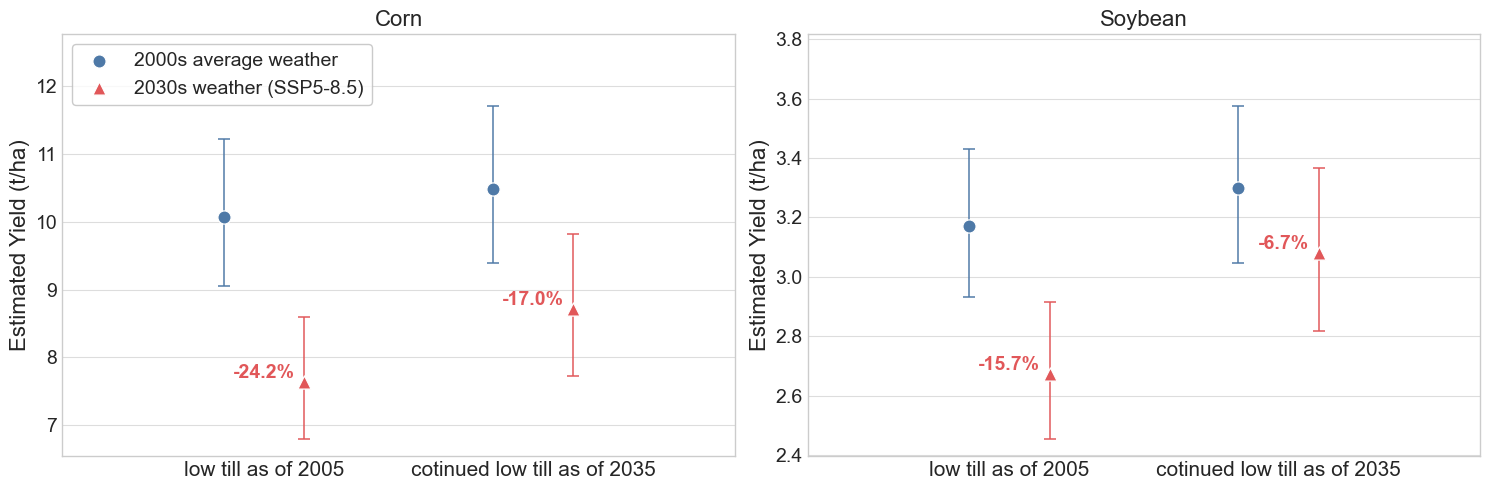

Saved: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/output_scenario_1999_2023/edd_binned_fitted_yields_2005_year_fe_duration_scenarios_no_irrigation/figures/fitted_yield_four_scenarios_grouped_by_duration_with_changes.png


In [17]:
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DURATION_ORDER = ["2005 duration", "Continued low till"]

WEATHER_ORDER = [
    "2000s weather (2000-2009)",
    "2030s weather (SSP5-8.5)",
]

WEATHER_LABELS = {
    "2000s weather (2000-2009)": "2000s average weather",
    "2030s weather (SSP5-8.5)": "2030s weather (SSP5-8.5)",
}

WEATHER_STYLES = {
    "2000s weather (2000-2009)": {
        "color": "#4E79A7",
        "marker": "o",
    },
    "2030s weather (SSP5-8.5)": {
        "color": "#E15759",
        "marker": "^",
    },
}


def plot_four_scenario_scatter_by_duration(
    summary: pd.DataFrame,
    out_dir: Path,
) -> Path:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5),
        sharey=False,
    )

    x = np.arange(len(DURATION_ORDER)) / 5

    weather_offsets = {
        "2000s weather (2000-2009)": -0.03,
        "2030s weather (SSP5-8.5)": 0.03,
    }

    for ax, crop_label in zip(axes, ["Corn", "Soybean"]):
        crop_data = summary.loc[summary["crop_label"].eq(crop_label)].copy()

        baseline = (
            crop_data.loc[
                crop_data["scenario_label"].eq("2000s weather (2000-2009)")
            ]
            .set_index("duration_scenario_label")
            .reindex(DURATION_ORDER)
        )

        baseline_yield = baseline["area_weighted_fitted_yield"].to_numpy(dtype=float)

        for weather_label in WEATHER_ORDER:
            style = WEATHER_STYLES[weather_label]

            d = (
                crop_data.loc[crop_data["scenario_label"].eq(weather_label)]
                .set_index("duration_scenario_label")
                .reindex(DURATION_ORDER)
            )

            y = d["area_weighted_fitted_yield"].to_numpy(dtype=float)
            low = d["area_weighted_fitted_yield_ci_low"].to_numpy(dtype=float)
            high = d["area_weighted_fitted_yield_ci_high"].to_numpy(dtype=float)

            x_values = x + weather_offsets[weather_label]

            ax.errorbar(
                x_values,
                y,
                yerr=np.vstack([
                    np.maximum(0, y - low),
                    np.maximum(0, high - y),
                ]),
                fmt="none",
                ecolor=style["color"],
                elinewidth=1.2,
                capsize=4,
                capthick=1.2,
                alpha=0.9,
                zorder=3,
            )

            ax.scatter(
                x_values,
                y,
                color=style["color"],
                marker=style["marker"],
                s=90,
                edgecolor="white",
                linewidth=0.9,
                label=WEATHER_LABELS[weather_label],
                zorder=4,
            )

            if weather_label != "2000s weather (2000-2009)":
                change_pct = np.where(
                    np.isfinite(baseline_yield) & (baseline_yield != 0),
                    100 * (y / baseline_yield - 1),
                    np.nan,
                )

                for x_pos, yield_value, pct in zip(x_values, y, change_pct):
                    if not np.isfinite(yield_value) or not np.isfinite(pct):
                        continue

                    ax.annotate(
                        f"{pct:+.1f}%",
                        xy=(x_pos, yield_value),
                        xytext=(-7, 0),
                        textcoords="offset points",
                        ha="right",
                        va="bottom",
                        fontsize=14,
                        color=style["color"],
                        fontweight="bold",
                        zorder=5,
                    )

        ax.set_title(crop_label, fontsize=16)
        ax.set_xlim(-0.15, x[-1] + 0.15)
        ax.set_xticks(x)
        ax.set_xticklabels(
            ["low till as of 2005", "cotinued low till as of 2035"],
            fontsize=15,
        )

        ax.set_ylabel("Estimated Yield (t/ha)", fontsize=16)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
        ax.grid(axis="x", visible=False)
        
        
        y_low, y_high = ax.get_ylim()
        y_span = y_high - y_low
        ax.set_ylim(y_low, y_high + 0.15 * y_span)
            

    handles, labels = axes[0].get_legend_handles_labels()
    legend_items = dict(zip(labels, handles))

    axes[0].legend(
        legend_items.values(),
        legend_items.keys(),
        frameon=True,
        edgecolor="#BDBDBD",
        facecolor="white",
        loc="upper left",
        fontsize=14,
    )

    fig.tight_layout()

    out_path = (
        out_dir
        / "fitted_yield_four_scenarios_grouped_by_duration_with_changes.png"
    )

    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return out_path


scenario_scatter = plot_four_scenario_scatter_by_duration(
    fitted_summary,
    FIGURE_DIR,
)

print(f"Saved: {scenario_scatter}")